In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42
print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
# Load the dataset
df_raw = pd.read_csv('Telco_Customer_Churn.csv')
print(f"Dataset shape: {df_raw.shape}")
df_raw.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Data types and basic info
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# Basic descriptive statistics for numerical columns
df_raw.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
# Fix TotalCharges: convert to numeric (spaces become NaN)
df = df_raw.copy()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# These 11 rows are new customers (tenure=0) — drop them
df.dropna(subset=['TotalCharges'], inplace=True)

# Drop customerID
df.drop(columns=['customerID'], inplace=True)

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"\nCleaned dataset shape: {df.shape}")

Missing values per column:
TotalCharges    11
dtype: int64

Cleaned dataset shape: (7032, 20)


Class distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64

Churn rate: 26.58%


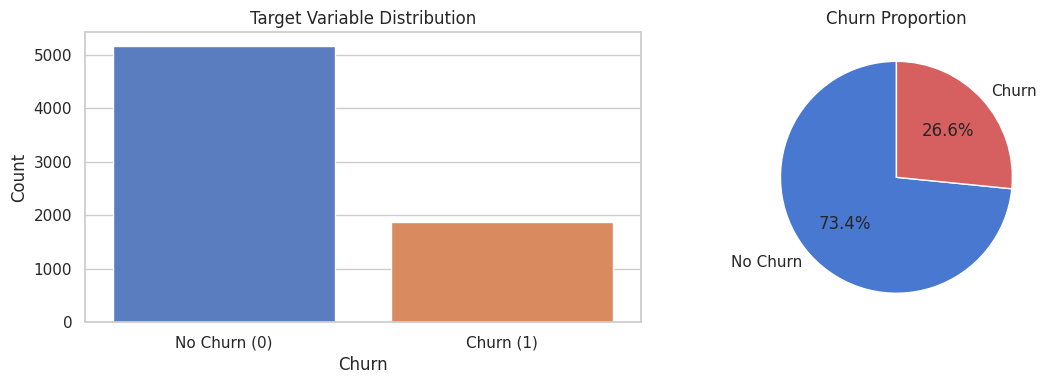


Discussion: The dataset is moderately imbalanced (~26% churners). 
This means accuracy alone is misleading — a model predicting 'No Churn' 
for every customer would achieve 74% accuracy without learning anything useful.
We will use ROC-AUC and F1-score (weighted) as primary evaluation metrics,
and stratified splits/cross-validation to preserve class proportions.


In [7]:
# Class distribution
churn_counts = df['Churn'].value_counts()
print("Class distribution:")
print(churn_counts)
print(f"\nChurn rate: {churn_counts[1] / len(df):.2%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(x='Churn', data=df, palette='muted', ax=axes[0])
axes[0].set_xticklabels(['No Churn (0)', 'Churn (1)'])
axes[0].set_title('Target Variable Distribution')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%',
            colors=['#4878CF', '#D65F5F'], startangle=90)
axes[1].set_title('Churn Proportion')

plt.tight_layout()
plt.show()

print("""
Discussion: The dataset is moderately imbalanced (~26% churners).
This means accuracy alone is misleading — a model predicting 'No Churn'
for every customer would achieve 74% accuracy without learning anything useful.
We will use ROC-AUC and F1-score (weighted) as primary evaluation metrics,
and stratified splits/cross-validation to preserve class proportions.""")

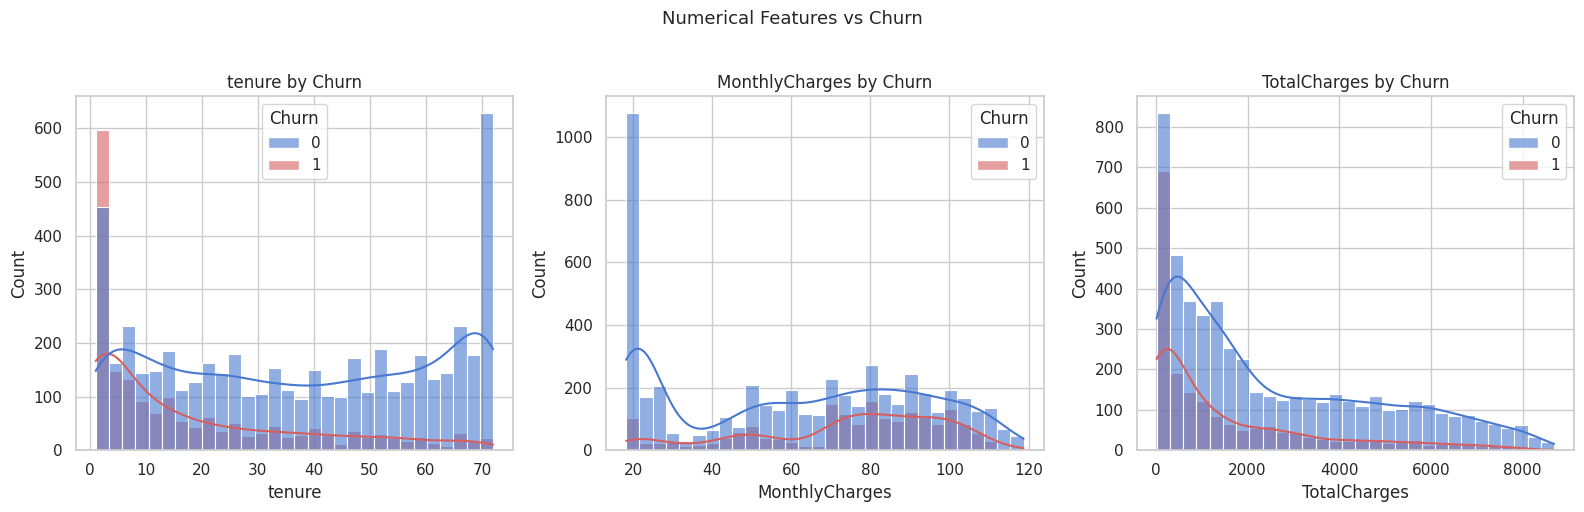

In [9]:
# Numerical feature distributions by churn
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue='Churn', kde=True, bins=30,
                 palette={0: '#4878CF', 1: '#D65F5F'}, ax=ax, alpha=0.6)
    ax.set_title(f'{col} by Churn')
plt.suptitle('Numerical Features vs Churn', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

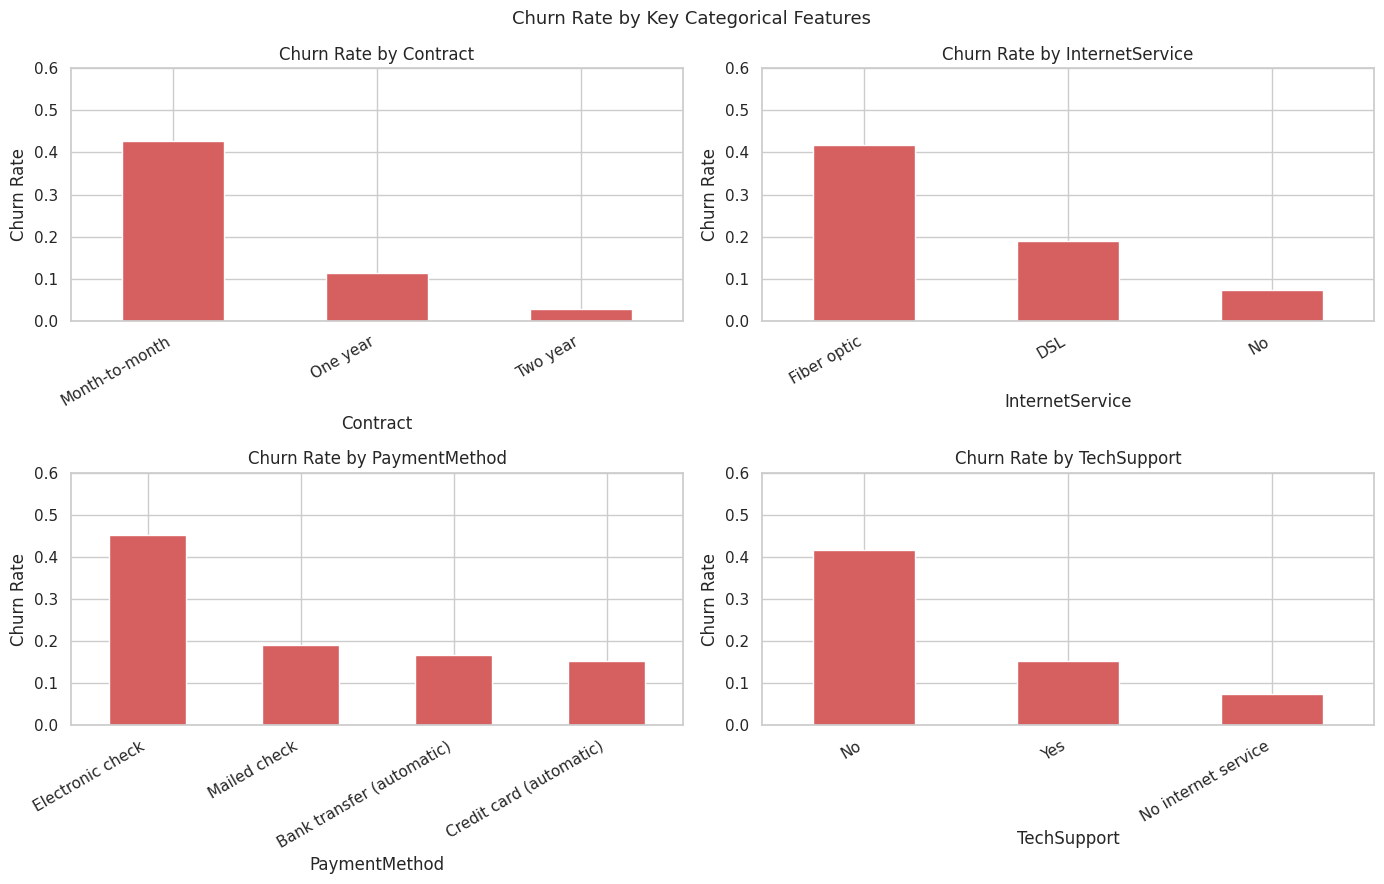

In [10]:
# Key categorical features vs Churn
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flatten(), cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=ax, color='#D65F5F', edgecolor='white')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.set_ylim(0, 0.6)
plt.suptitle('Churn Rate by Key Categorical Features', fontsize=13)
plt.tight_layout()
plt.show()

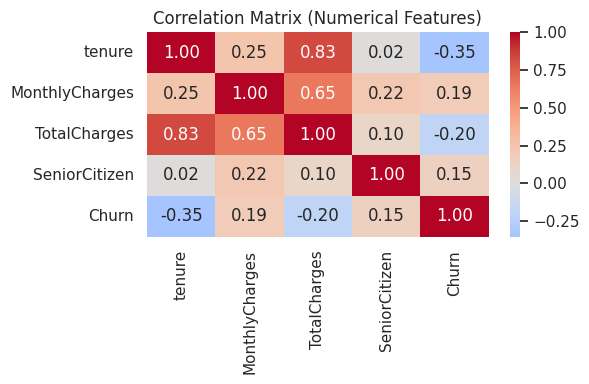


Key EDA Findings:
• Customers on Month-to-month contracts churn at ~43% vs ~11% for Two-year contracts.
• Fiber optic internet users churn significantly more than DSL users.
• Short-tenure customers (< 12 months) are the highest-risk group.
• Higher MonthlyCharges correlate with increased churn.
• Lack of TechSupport and OnlineSecurity strongly associates with churn.


In [11]:
# Correlation heatmap (numerical features only)
plt.figure(figsize=(6, 4))
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix (Numerical Features)')
plt.tight_layout()
plt.show()

print("""
Key EDA Findings:
• Customers on Month-to-month contracts churn at ~43% vs ~11% for Two-year contracts.
• Fiber optic internet users churn significantly more than DSL users.
• Short-tenure customers (< 12 months) are the highest-risk group.
• Higher MonthlyCharges correlate with increased churn.
• Lack of TechSupport and OnlineSecurity strongly associates with churn.""")

In [12]:
# ── Define feature sets ──────────────────────────────────────────────────────

# Binary Yes/No columns → map to 0/1
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
internet_binary = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                   'TechSupport', 'StreamingTV', 'StreamingMovies']

# Multi-category columns → OrdinalEncoder
multi_cols = ['gender', 'MultipleLines', 'InternetService', 'Contract', 'PaymentMethod']

# Numerical columns (pass through)
num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

# Apply binary mapping manually (safe: no fit required for deterministic maps)
map_yes_no = {'Yes': 1, 'No': 0,
              'No phone service': 0, 'No internet service': 0}

df_proc = df.copy()
for col in binary_cols + internet_binary:
    df_proc[col] = df_proc[col].map(map_yes_no)

# Feature engineering: tenure groups (domain knowledge)
df_proc['tenure_group'] = pd.cut(df_proc['tenure'],
                                  bins=[0, 12, 24, 48, 72],
                                  labels=[0, 1, 2, 3]).astype(int)

# Define X and y
FEATURE_COLS = num_cols + binary_cols + internet_binary + multi_cols + ['tenure_group']
X = df_proc[FEATURE_COLS]
y = df_proc['Churn']

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts(normalize=True).round(3))

Feature matrix shape: (7032, 20)
Target distribution:
Churn
0    0.734
1    0.266
Name: proportion, dtype: float64


In [13]:
# ── Train / Test Split (stratified, 80/20) ───────────────────────────────────
# IMPORTANT: split BEFORE any encoder fitting to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set  : {X_train.shape[0]} samples")
print(f"Test set      : {X_test.shape[0]} samples")
print(f"Train churn % : {y_train.mean():.2%}")
print(f"Test  churn % : {y_test.mean():.2%}")

Training set  : 5625 samples
Test set      : 1407 samples
Train churn % : 26.58%
Test  churn % : 26.58%


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Columns needing OrdinalEncoder (multi-category strings)
ord_cols = multi_cols  # ['gender','MultipleLines','InternetService','Contract','PaymentMethod']
# All remaining features are already numeric
pass_cols = num_cols + binary_cols + internet_binary + ['tenure_group']

# Preprocessing sub-pipeline
preprocessor = ColumnTransformer(transformers=[
    ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ord_cols),
    ('num', StandardScaler(), pass_cols)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = 'roc_auc'

print("Preprocessing pipeline defined.")
print(f"Ordinal-encoded columns : {ord_cols}")
print(f"Scaled numeric columns  : {pass_cols}")

Preprocessing pipeline defined.
Ordinal-encoded columns : ['gender', 'MultipleLines', 'InternetService', 'Contract', 'PaymentMethod']
Scaled numeric columns  : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'tenure_group']


In [15]:
# ── 4a. Logistic Regression ──────────────────────────────────────────────────
pipe_lr = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'))
])

param_grid_lr = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__solver': ['lbfgs', 'liblinear']
}

gs_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=cv, scoring=scoring, n_jobs=-1, verbose=0)
gs_lr.fit(X_train, y_train)

print("Logistic Regression – Best params:", gs_lr.best_params_)
print(f"Logistic Regression – Best CV ROC-AUC: {gs_lr.best_score_:.4f}")

Logistic Regression – Best params: {'clf__C': 10, 'clf__solver': 'liblinear'}
Logistic Regression – Best CV ROC-AUC: 0.8445


In [16]:
# ── 4b. Random Forest ────────────────────────────────────────────────────────
pipe_rf = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'))
])

param_grid_rf = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5]
}

gs_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=cv, scoring=scoring, n_jobs=-1, verbose=0)
gs_rf.fit(X_train, y_train)

print("Random Forest – Best params:", gs_rf.best_params_)
print(f"Random Forest – Best CV ROC-AUC: {gs_rf.best_score_:.4f}")

Random Forest – Best params: {'clf__max_depth': 10, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Random Forest – Best CV ROC-AUC: 0.8470


In [17]:
# ── 4c. Gradient Boosting ────────────────────────────────────────────────────
pipe_gb = Pipeline([
    ('pre', preprocessor),
    ('clf', GradientBoostingClassifier(random_state=RANDOM_STATE))
])

param_grid_gb = {
    'clf__n_estimators': [100, 200],
    'clf__learning_rate': [0.05, 0.1],
    'clf__max_depth': [3, 5]
}

gs_gb = GridSearchCV(pipe_gb, param_grid_gb, cv=cv, scoring=scoring, n_jobs=-1, verbose=0)
gs_gb.fit(X_train, y_train)

print("Gradient Boosting – Best params:", gs_gb.best_params_)
print(f"Gradient Boosting – Best CV ROC-AUC: {gs_gb.best_score_:.4f}")

Gradient Boosting – Best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 100}
Gradient Boosting – Best CV ROC-AUC: 0.8476


Cross-Validation Results (5-Fold Stratified, ROC-AUC):
                     CV ROC-AUC
Gradient Boosting        0.8476
Random Forest            0.8470
Logistic Regression      0.8445


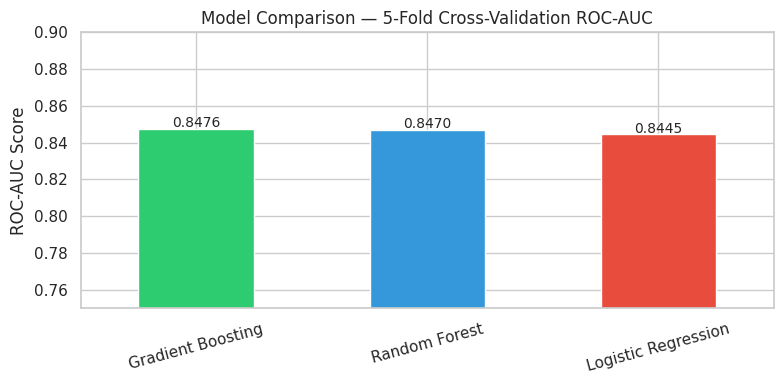


→ Best model selected: Gradient Boosting


In [18]:
# ── Model Comparison ─────────────────────────────────────────────────────────
results = {
    'Logistic Regression': gs_lr.best_score_,
    'Random Forest':       gs_rf.best_score_,
    'Gradient Boosting':   gs_gb.best_score_,
}

results_df = pd.DataFrame.from_dict(results, orient='index', columns=['CV ROC-AUC'])
results_df = results_df.sort_values('CV ROC-AUC', ascending=False)
print("Cross-Validation Results (5-Fold Stratified, ROC-AUC):")
print(results_df.round(4))

plt.figure(figsize=(8, 4))
ax = results_df['CV ROC-AUC'].plot(kind='bar', color=['#2ecc71','#3498db','#e74c3c'][:len(results_df)],
                                    edgecolor='white', width=0.5)
ax.set_ylim(0.75, 0.90)
ax.set_ylabel('ROC-AUC Score')
ax.set_title('Model Comparison — 5-Fold Cross-Validation ROC-AUC')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width()/2, p.get_height() + 0.001),
                ha='center', fontsize=10)
plt.tight_layout()
plt.show()

best_name = results_df.index[0]
print(f"\n→ Best model selected: {best_name}")

In [20]:
# Select best grid-search object
best_gs = {'Logistic Regression': gs_lr,
           'Random Forest': gs_rf,
           'Gradient Boosting': gs_gb}[best_name]

best_model = best_gs.best_estimator_

# ── Test-set predictions ──────────────────────────────────────────────────────
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

test_auc  = roc_auc_score(y_test, y_proba)
test_acc  = accuracy_score(y_test, y_pred)
test_f1   = f1_score(y_test, y_pred, average='weighted')

print(f"{'='*50}")
print(f" Final Model : {best_name}")
print(f"{'='*50}")
print(f" ROC-AUC     : {test_auc:.4f}")
print(f" Accuracy    : {test_acc:.4f}")
print(f" F1 (weighted): {test_f1:.4f}")
print(f"{'='*50}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

 Final Model : Gradient Boosting
 ROC-AUC     : 0.8372
 Accuracy    : 0.7960
 F1 (weighted): 0.7870

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.87      1033
       Churn       0.65      0.50      0.57       374

    accuracy                           0.80      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.80      0.79      1407



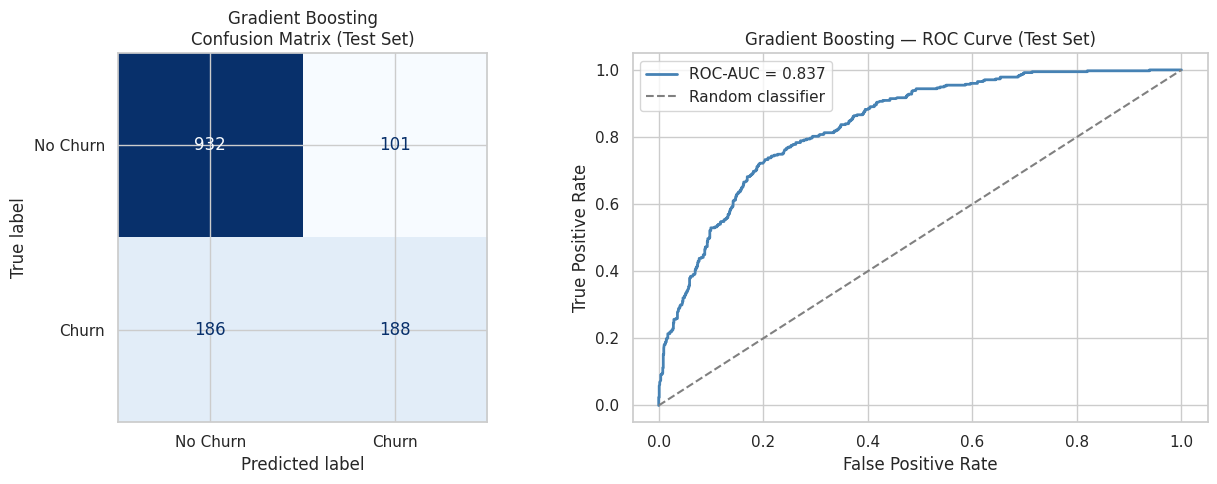

In [21]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'{best_name}\nConfusion Matrix (Test Set)')

# ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC-AUC = {test_auc:.3f}')
axes[1].plot([0,1],[0,1],'--', color='gray', label='Random classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'{best_name} — ROC Curve (Test Set)')
axes[1].legend()
plt.tight_layout()
plt.show()

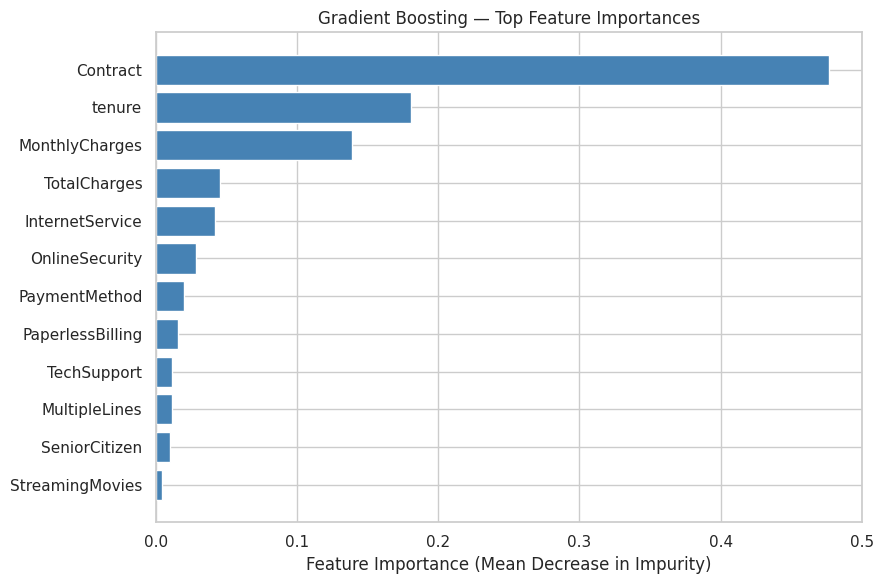


Interpretation: Features with the highest importance / largest absolute coefficients
are the primary drivers of churn prediction. Positive coefficients (red bars) increase
the probability of churn; negative ones (blue bars) decrease it.


In [22]:
# Feature importance — works for Random Forest and Gradient Boosting
import inspect

clf_step = best_model.named_steps['clf']

if hasattr(clf_step, 'feature_importances_'):
    # Get feature names from the preprocessor
    ord_feat_names = ord_cols
    num_feat_names = pass_cols
    all_feat_names = ord_feat_names + num_feat_names

    importances = clf_step.feature_importances_
    imp_df = pd.DataFrame({'Feature': all_feat_names, 'Importance': importances})
    imp_df = imp_df.sort_values('Importance', ascending=True).tail(12)

    plt.figure(figsize=(9, 6))
    plt.barh(imp_df['Feature'], imp_df['Importance'], color='steelblue', edgecolor='white')
    plt.xlabel('Feature Importance (Mean Decrease in Impurity)')
    plt.title(f'{best_name} — Top Feature Importances')
    plt.tight_layout()
    plt.show()

elif hasattr(clf_step, 'coef_'):
    # Logistic Regression coefficients
    ord_feat_names = ord_cols
    num_feat_names = pass_cols
    all_feat_names = ord_feat_names + num_feat_names

    coef = clf_step.coef_[0]
    coef_df = pd.DataFrame({'Feature': all_feat_names, 'Coefficient': coef})
    coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=True).index).tail(12)

    colors = ['#D65F5F' if c > 0 else '#4878CF' for c in coef_df['Coefficient']]
    plt.figure(figsize=(9, 6))
    plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
    plt.axvline(0, color='black', linewidth=0.8)
    plt.xlabel('Logistic Regression Coefficient (log-odds)')
    plt.title('Feature Coefficients — Logistic Regression')
    plt.tight_layout()
    plt.show()

print("""
Interpretation: Features with the highest importance / largest absolute coefficients
are the primary drivers of churn prediction. Positive coefficients (red bars) increase
the probability of churn; negative ones (blue bars) decrease it.""")